In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from textwrap import fill
import numpy as np
import pandas as pd
import scanpy.external as sce
import scanpy as sc
import anndata as an
from scipy.spatial.distance import cdist
import scvelo as scv
import gget
import re
# import rapids_singlecell as rsc
from scipy.stats import linregress
from scipy.stats import spearmanr
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import zscore
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from tqdm import tqdm
from statsmodels.stats.multitest import multipletests

# import cellrank as cr

sc.settings.verbosity = 3 

print(scv.__version__)

import warnings
warnings.filterwarnings("ignore")

import logging
logging.getLogger('py.warnings').setLevel(logging.ERROR)

0.3.3


# Load data

In [2]:
%%time
fpath = "/scratch/indikar_root/indikar1/shared_data/HYB/scvelo/scvelo.h5ad"
adata = sc.read_h5ad(fpath)

adata

CPU times: user 704 ms, sys: 15 s, total: 15.7 s
Wall time: 1min 41s


AnnData object with n_obs × n_vars = 15950 × 25042
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split', 'velocyto_cell_id', 'cell_id', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'velocity_self_transition', 'velocity_pseudotime', 'G1_velocity_pseudotime', 'G2M_velocity_pseudotime', 'mean_velocity_pseudotime'
    var: 'gene_id', 'gene_ty

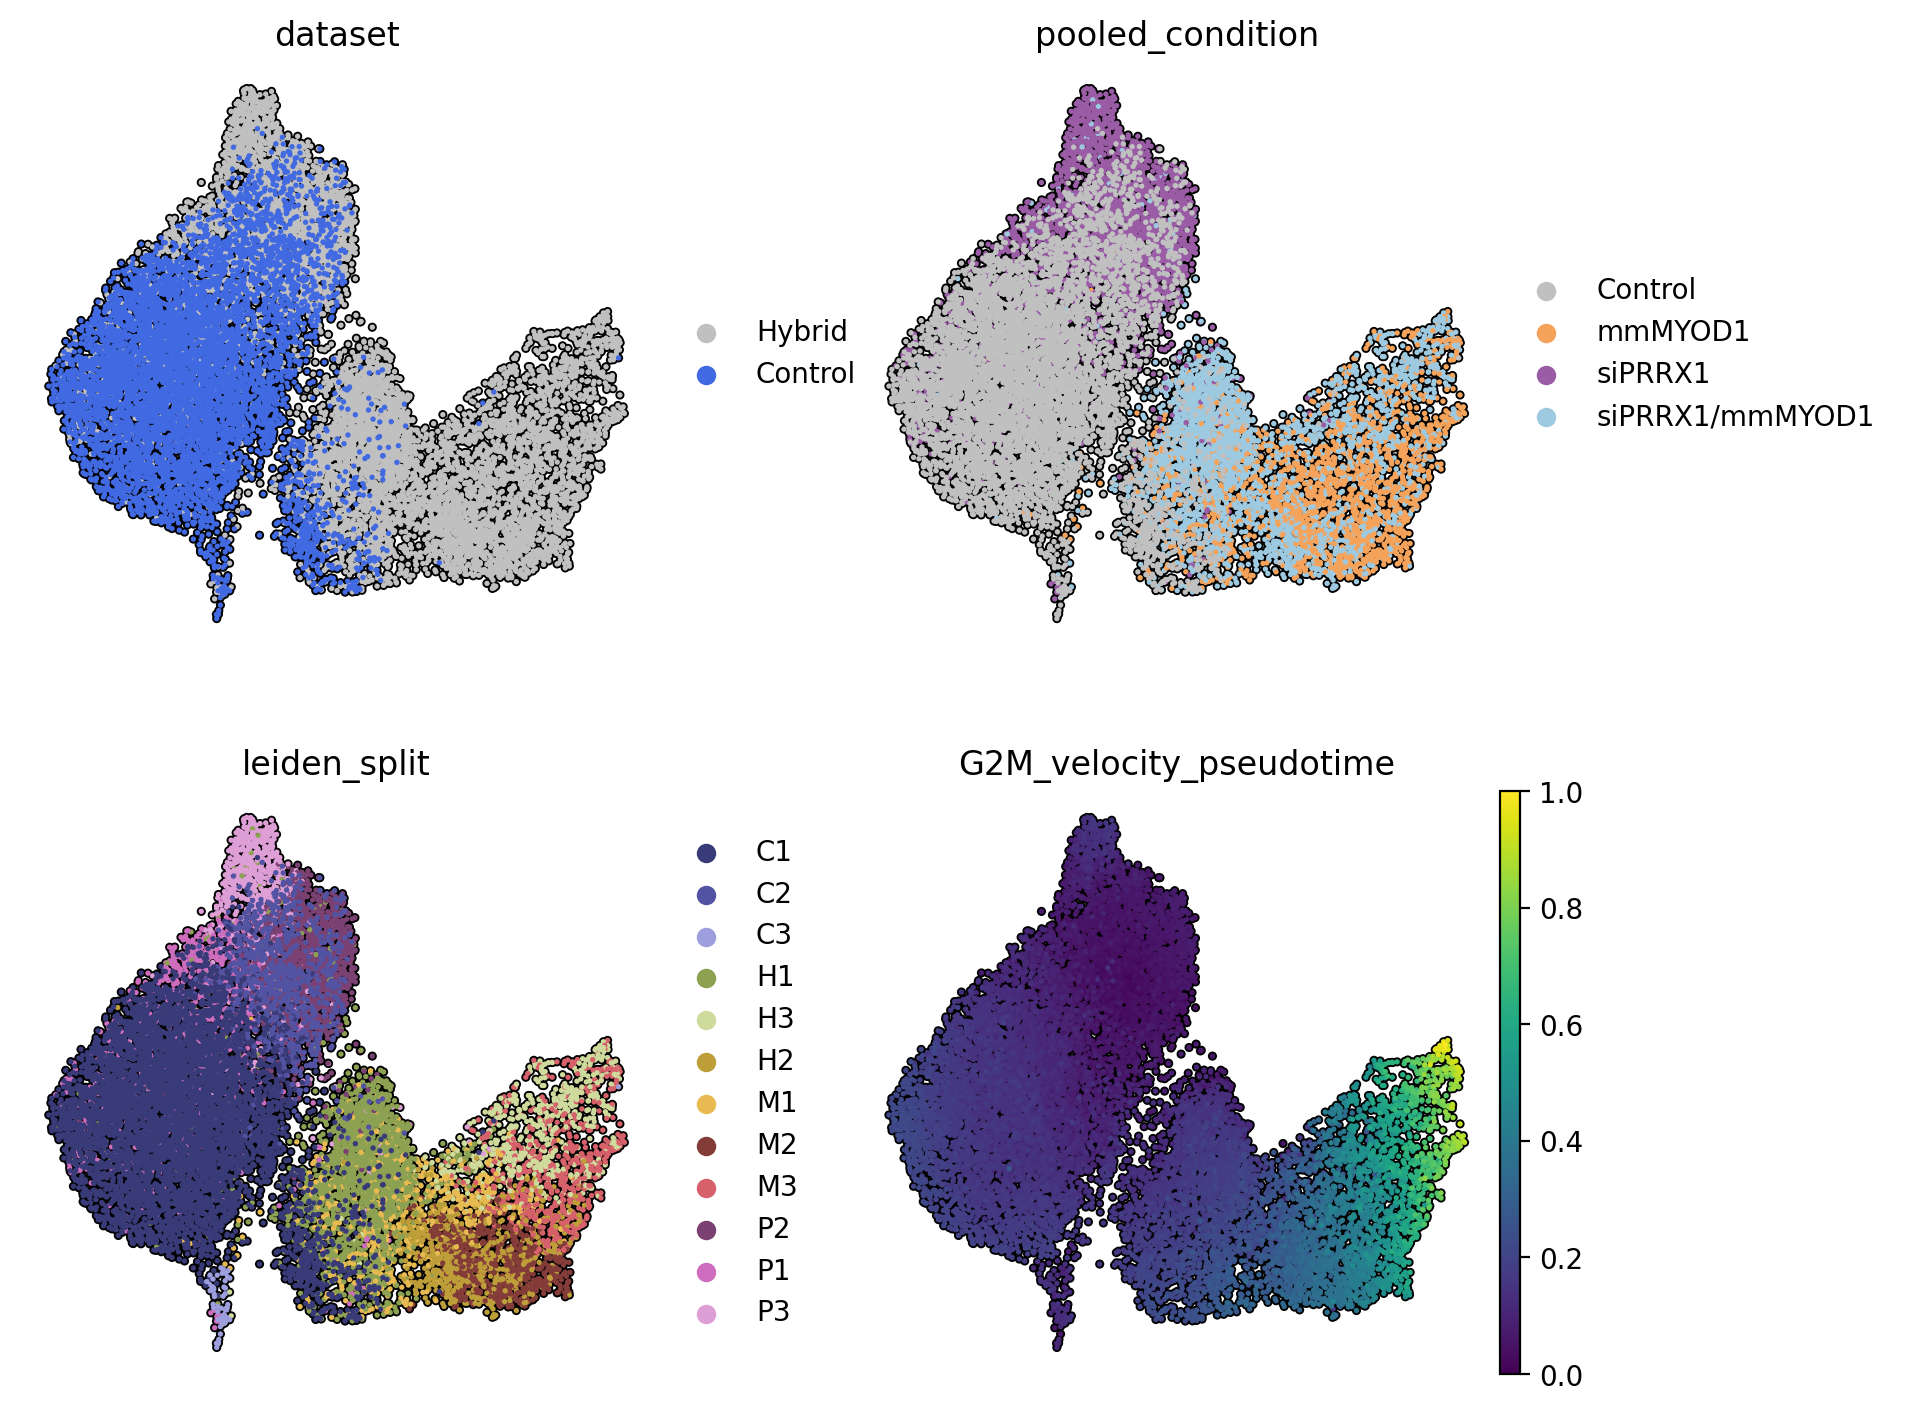

In [3]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata,
    color=['dataset', 'pooled_condition', 'leiden_split', 'G2M_velocity_pseudotime'],
    size=15,
    ncols=2,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    alpha=1,
)

# Correlations

In [4]:
layer = 'spliced'

pt = adata.obs['G2M_velocity_pseudotime']
X = adata[:, :].layers[layer].toarray()

# remove genes with all 0s or very little variance
valid_genes = []
for i in range(X.shape[1]):
    # Check if the gene vector has at least 2 unique values
    if len(np.unique(X[:, i])) > 1:
        valid_genes.append(i)

print(len(valid_genes))

cors = []
pvals = []
    
for i in tqdm(valid_genes, desc="Computing Spearman Correlation"):
    corr, pval = spearmanr(X[:, i], pt)
    cors.append(corr)
    pvals.append(pval)

cors = np.array(cors)
pvals = np.array(pvals)

# FDR correction
reject, pvals_fdr, _, _ = multipletests(pvals, alpha=0.05, method='fdr_bh')

# gene_names = adata.var_names
gene_names = adata.var_names[valid_genes]

cors_df = pd.DataFrame({
    'gene': gene_names,
    'correlation': cors,
    'p_value': pvals,
    'p_value_fdr': pvals_fdr,
    'significant': reject
})

print(cors_df.shape)

cors_df = cors_df[cors_df['significant']]

print(cors_df.shape)
display(cors_df.head())

# Select top genes
n_genes = 20

top_pos = list(cors_df.sort_values(by='correlation', ascending=False).head(n_genes)['gene'].unique())
top_neg = list(cors_df.sort_values(by='correlation', ascending=True).head(n_genes)['gene'].unique())

top_neg.reverse()

selected_genes = top_pos + top_neg

print(len(selected_genes))

21088


Computing Spearman Correlation: 100%|██████████| 21088/21088 [01:00<00:00, 350.47it/s]


(21088, 5)
(10597, 5)


,gene,correlation,p_value,p_value_fdr,significant
6,AAAS,-0.055823,1.725119e-12,8.610487e-12,True
7,AACS,-0.048399,9.623305e-10,4.139022e-09,True
8,AADACP1,0.020501,9.619944e-03,2.092906e-02,True
9,AADAT,-0.025400,1.336245e-03,3.337923e-03,True
11,AAK1,-0.106959,8.362331e-42,1.031256e-40,True


Using layer=spliced...


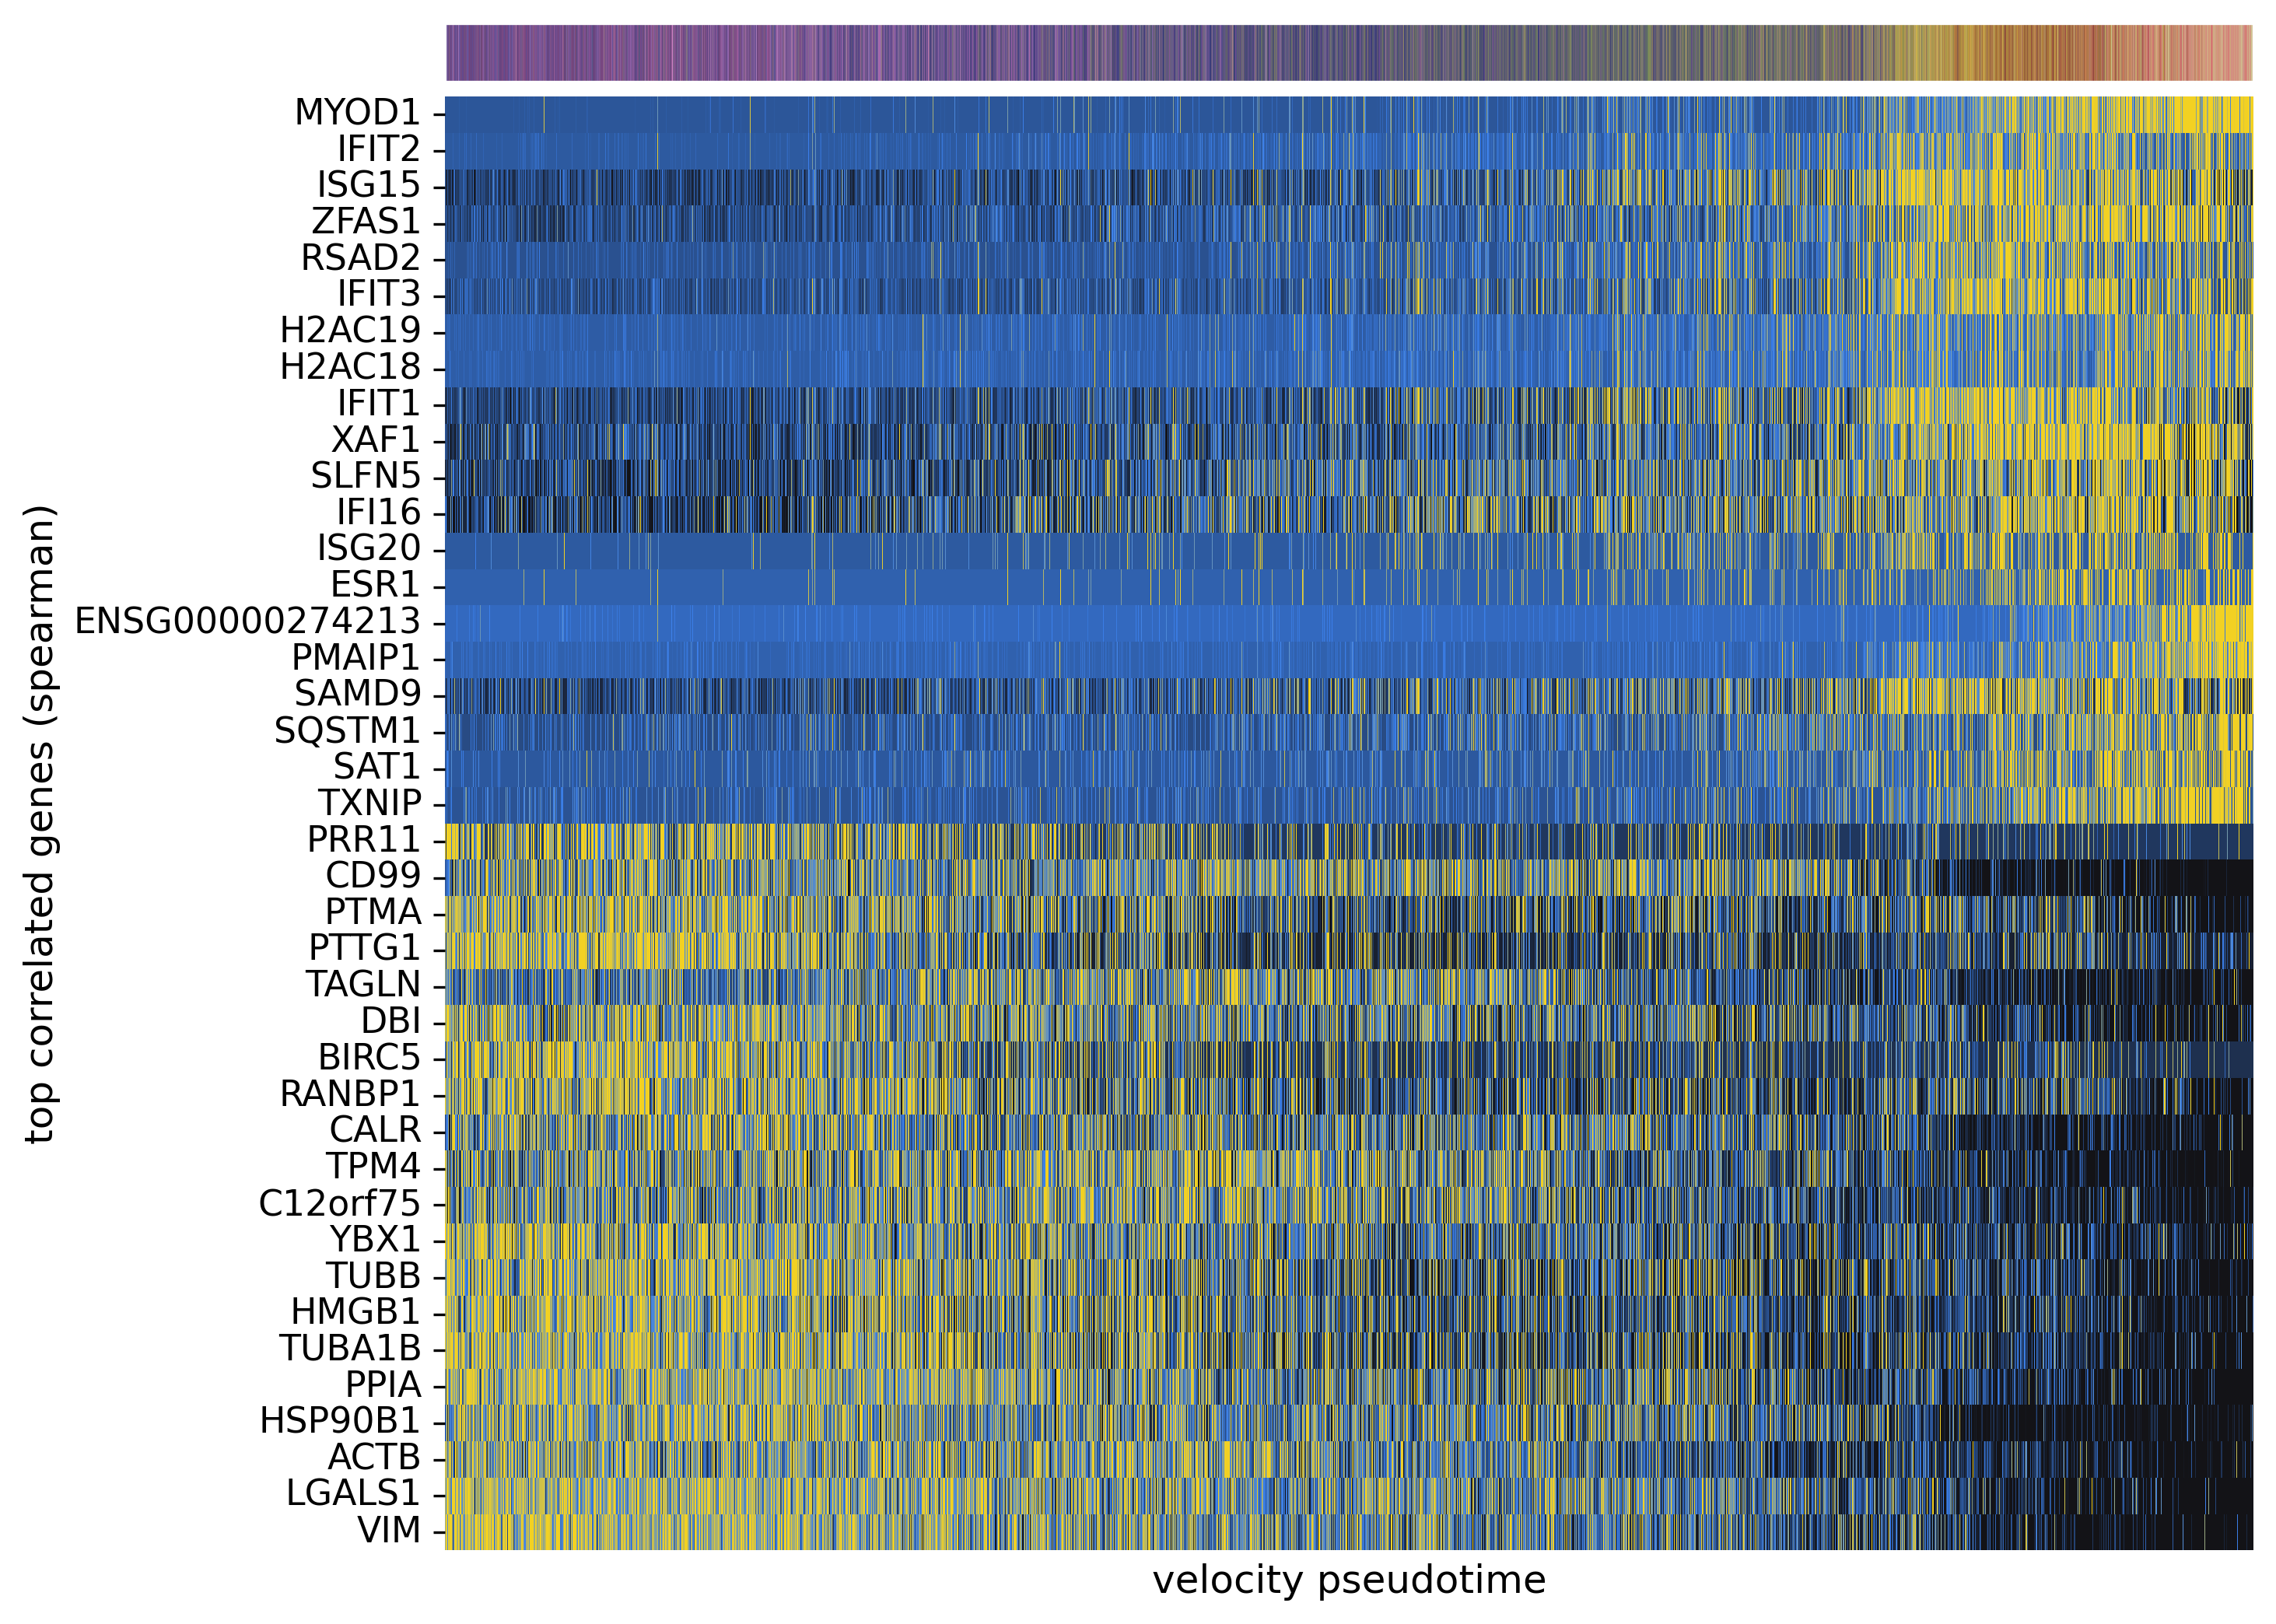

In [11]:
from matplotlib import gridspec
from matplotlib.colors import to_rgba
from matplotlib.colors import LinearSegmentedColormap

low = '#131317' # dark
mid = '#3B80EB' # blue
high = '#F2D123' # yellow

custom_cmap = LinearSegmentedColormap.from_list(
    "custom_cmap",
    [(0.0, low), (0.15, low), (0.5, mid), (0.85, high), (1.0, high)]
)

cell_order = adata.obs.sort_values("G2M_velocity_pseudotime").index
n_cells = len(cell_order)

print(f"Using layer={layer}...")
adata.X = adata.layers[layer].copy()

expr = adata[cell_order, selected_genes].X
if not isinstance(expr, np.ndarray):
    expr = expr.toarray()

# z-score expression
expr_z = zscore(expr, axis=0)

# get bar for cluster order
clusters = adata.obs.loc[cell_order, 'leiden_split']

# mapping: category → color
cluster_colors = dict(zip(
    adata.obs['leiden_split'].cat.categories,
    adata.uns['leiden_split_colors']
))

# convert cluster labels to colors for each cell in order
col_colors = clusters.map(cluster_colors).to_numpy()
rgba_colors = np.array([to_rgba(c) for c in col_colors])


fig = plt.figure(figsize=(10, 8.5), dpi=300)

gs = gridspec.GridSpec(
    2, 1, 
    height_ratios=[0.4, 10],   # small top bar, big heatmap
    hspace=0.02                 # small spacing
)

# --- Top colorbar axis (tiny horizontal strip) ---
ax_color = fig.add_subplot(gs[0])

ax_color.imshow(rgba_colors[np.newaxis, :, :], aspect='auto')
ax_color.set_xlim(0, n_cells)
ax_color.set_xticks([])
ax_color.set_yticks([])
for spine in ax_color.spines.values():
    spine.set_edgecolor('white')

ax_heat = fig.add_subplot(gs[1])

sns.heatmap(
    expr_z.T,
    cmap=custom_cmap,
    xticklabels=False,
    yticklabels=selected_genes,
    vmin=-1.5,
    vmax=1.5,
    cbar=False,
    ax=ax_heat,
)
ax_heat.set_yticklabels(ax_heat.get_yticklabels(), fontsize=11)
ax_heat.set_xlabel("velocity pseudotime", fontsize=12)
ax_heat.set_ylabel("top correlated genes (spearman)", fontsize=12)

plt.tight_layout()
plt.show()

# enrichr

In [16]:
print(cors_df[cors_df['correlation'] > 0].shape)
print(cors_df[cors_df['correlation'] < 0].shape)

(4465, 5)
(6132, 5)


In [18]:
n_genes = 100

top_pos = list(cors_df.sort_values(by='correlation', ascending=False).head(n_genes)['gene'].unique())
top_neg = list(cors_df.sort_values(by='correlation', ascending=True).head(n_genes)['gene'].unique())


pd.set_option('display.max_colwidth', None)

# database = 'celltypes'
database = "GO_Biological_Process_2025"
# database="KEGG_2021_Human"
# database='MSigDB_Hallmark_2020' 
# database="Reactome_Pathways_2024"
# database = "CellMarker_2024"
# database='Tabula_Sapiens'


edf_pos = gget.enrichr(top_pos, database=database, save=False)
display(edf_pos[['path_name', 'overlapping_genes', 'adj_p_val']].head(15))
print("=" * 100 + "\n")

edf_neg = gget.enrichr(top_neg, database=database, save=False)
display(edf_neg[['path_name', 'overlapping_genes', 'adj_p_val']].head(15))
print("=" * 100 + "\n")

13:36:12 - INFO - Performing Enrichr analysis using database GO_Biological_Process_2025.


,path_name,overlapping_genes,adj_p_val
0,Defense Response to Virus (GO:0051607),"[RTP4, RSAD2, IFNB1, MX2, ISG15, IFIT1, USP18, IFIT3, IFIT2, ISG20, CXCL10, IL6, IFI16, IFI27, PMAIP1, RIGI]",3.103540e-12
1,Negative Regulation of Viral Process (GO:0048525),"[ISG20, CH25H, SP100, RSAD2, IFI16, IFNB1, CCL5, ISG15, IFIT1]",2.046736e-08
2,Positive Regulation of Apoptotic Process (GO:0043065),"[JUN, TNFRSF12A, GADD45B, GADD45A, IFNB1, IFIT2, IL6, DDIT3, TNFSF10, PMAIP1, CCL2, SQSTM1, PHLDA1, ATF4]",1.800219e-07
3,Regulation of Viral Genome Replication (GO:0045069),"[ISG20, CXCL8, RSAD2, IFI16, IFNB1, CCL5, ISG15, IFIT1]",3.438386e-07
4,Negative Regulation of Viral Genome Replication (GO:0045071),"[ISG20, IFI16, RSAD2, IFNB1, CCL5, ISG15, IFIT1]",8.134896e-07
5,Positive Regulation of Programmed Cell Death (GO:0043068),"[IL6, JUN, TNFRSF12A, GADD45B, GADD45A, TNFSF10, PMAIP1, SQSTM1, PHLDA1, IFIT2, ATF4]",7.893426e-06
6,Response to Cytokine (GO:0034097),"[CD274, CH25H, SP100, NUB1, MX2, ISG15, XAF1, RELB]",2.789711e-05
7,Positive Regulation of Transcription by RNA Polymerase II (GO:0045944),"[SP100, JUN, IFNB1, RIPK2, LIF, ESR1, RELB, NFKBIA, CXCL10, IL6, IFI16, MYOD1, DDIT3, MAFF, NCOA7, SQSTM1, ATF3, RIGI, ATF4]",4.525459e-05
8,Antiviral Innate Immune Response (GO:0140374),"[CXCL10, IFIT1, USP18, IFIT3, IFIT2, RIGI]",7.251026e-05
9,Integrated Stress Response Signaling (GO:0140467),"[HERC5, BATF2, JUN, DDIT3, ATF4]",7.251026e-05


13:36:12 - INFO - Performing Enrichr analysis using database GO_Biological_Process_2025.


,path_name,overlapping_genes,adj_p_val
0,Cytoskeleton-Dependent Cytokinesis (GO:0061640),"[ANLN, SEPTIN2, KIF4A, NUSAP1, CKAP2, BIRC5, KIF23, KIF20A, CEP55, RHOA, SEPTIN7]",3.213672e-10
1,Positive Regulation of Cell Cycle Process (GO:0090068),"[RANBP1, RRM1, NUSAP1, BIRC5, NCAPG, NCAPD2, KIF23, KIF20B, SMC4, NDC80, RHOA]",5.776824e-09
2,Mitotic Sister Chromatid Segregation (GO:0000070),"[TPX2, CCNB1, NUSAP1, BIRC5, NCAPG, NCAPD2, KIF23, SMC4, CEP55, NDC80, RHOA]",5.776824e-09
3,Mitotic Cytokinesis (GO:0000281),"[ANLN, KIF4A, NUSAP1, CKAP2, BIRC5, KIF23, KIF20A, CEP55]",1.675833e-07
4,Mitotic Spindle Organization (GO:0007052),"[TPX2, CCNB1, KIF4A, BIRC5, KIF23, RHOA, NDC80]",5.145072e-05
5,Positive Regulation of Chromosome Separation (GO:1905820),"[NCAPG, BIRC5, NCAPD2, SMC4]",5.145072e-05
6,Chromosome Condensation (GO:0030261),"[TOP2A, NUSAP1, NCAPG, NCAPD2, SMC4]",5.145072e-05
7,Microtubule Cytoskeleton Organization Involved in Mitosis (GO:1902850),"[CCNB1, KIF4A, NUSAP1, TACC3, BIRC5, NDC80]",5.145072e-05
8,Mitotic Chromosome Condensation (GO:0007076),"[NUSAP1, NCAPG, NCAPD2, SMC4]",9.576754e-05
9,Positive Regulation of Chromosome Segregation (GO:0051984),"[CCNB1, NCAPG, NCAPD2, SMC4]",1.438058e-04


# TFs

In [13]:
fpath = "../../resources/allTFs_hg38.txt"
tf_list = [x.strip() for x in open(fpath)]
tf_list[:10]

tdf = cors_df[cors_df['gene'].isin(tf_list)]
tdf = tdf.sort_values(by='correlation', ascending=False)
print("="*20 + " Positive Correlation " + "="*20)
print(tdf.head(15).to_string(index=False))
print()
print("="*20 + " Negative Correlation " + "="*20)
print(tdf.tail(15).to_string(index=False))

==================== Positive Correlation ====================
   gene  correlation       p_value   p_value_fdr  significant
  MYOD1     0.674966  0.000000e+00  0.000000e+00         True
   ESR1     0.418409  0.000000e+00  0.000000e+00         True
   ATF3     0.355072  0.000000e+00  0.000000e+00         True
  SP100     0.348006  0.000000e+00  0.000000e+00         True
GADD45A     0.292700  0.000000e+00  0.000000e+00         True
  DDIT3     0.290290 2.997169e-307 3.611674e-305         True
   MAFF     0.265712 6.518974e-256 6.192438e-254         True
   ATF4     0.261800 3.168628e-248 2.843405e-246         True
  CREB5     0.260837 2.356587e-246 2.105750e-244         True
   JUNB     0.238923 7.382404e-206 5.241755e-204         True
    JUN     0.225531 4.602490e-183 2.789003e-181         True
   RELB     0.224544 1.932863e-181 1.154680e-179         True
 ZNF844     0.218619 7.227238e-172 3.989738e-170         True
 ZBTB20     0.218053 5.744600e-171 3.154743e-169         True
  CEBPB

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


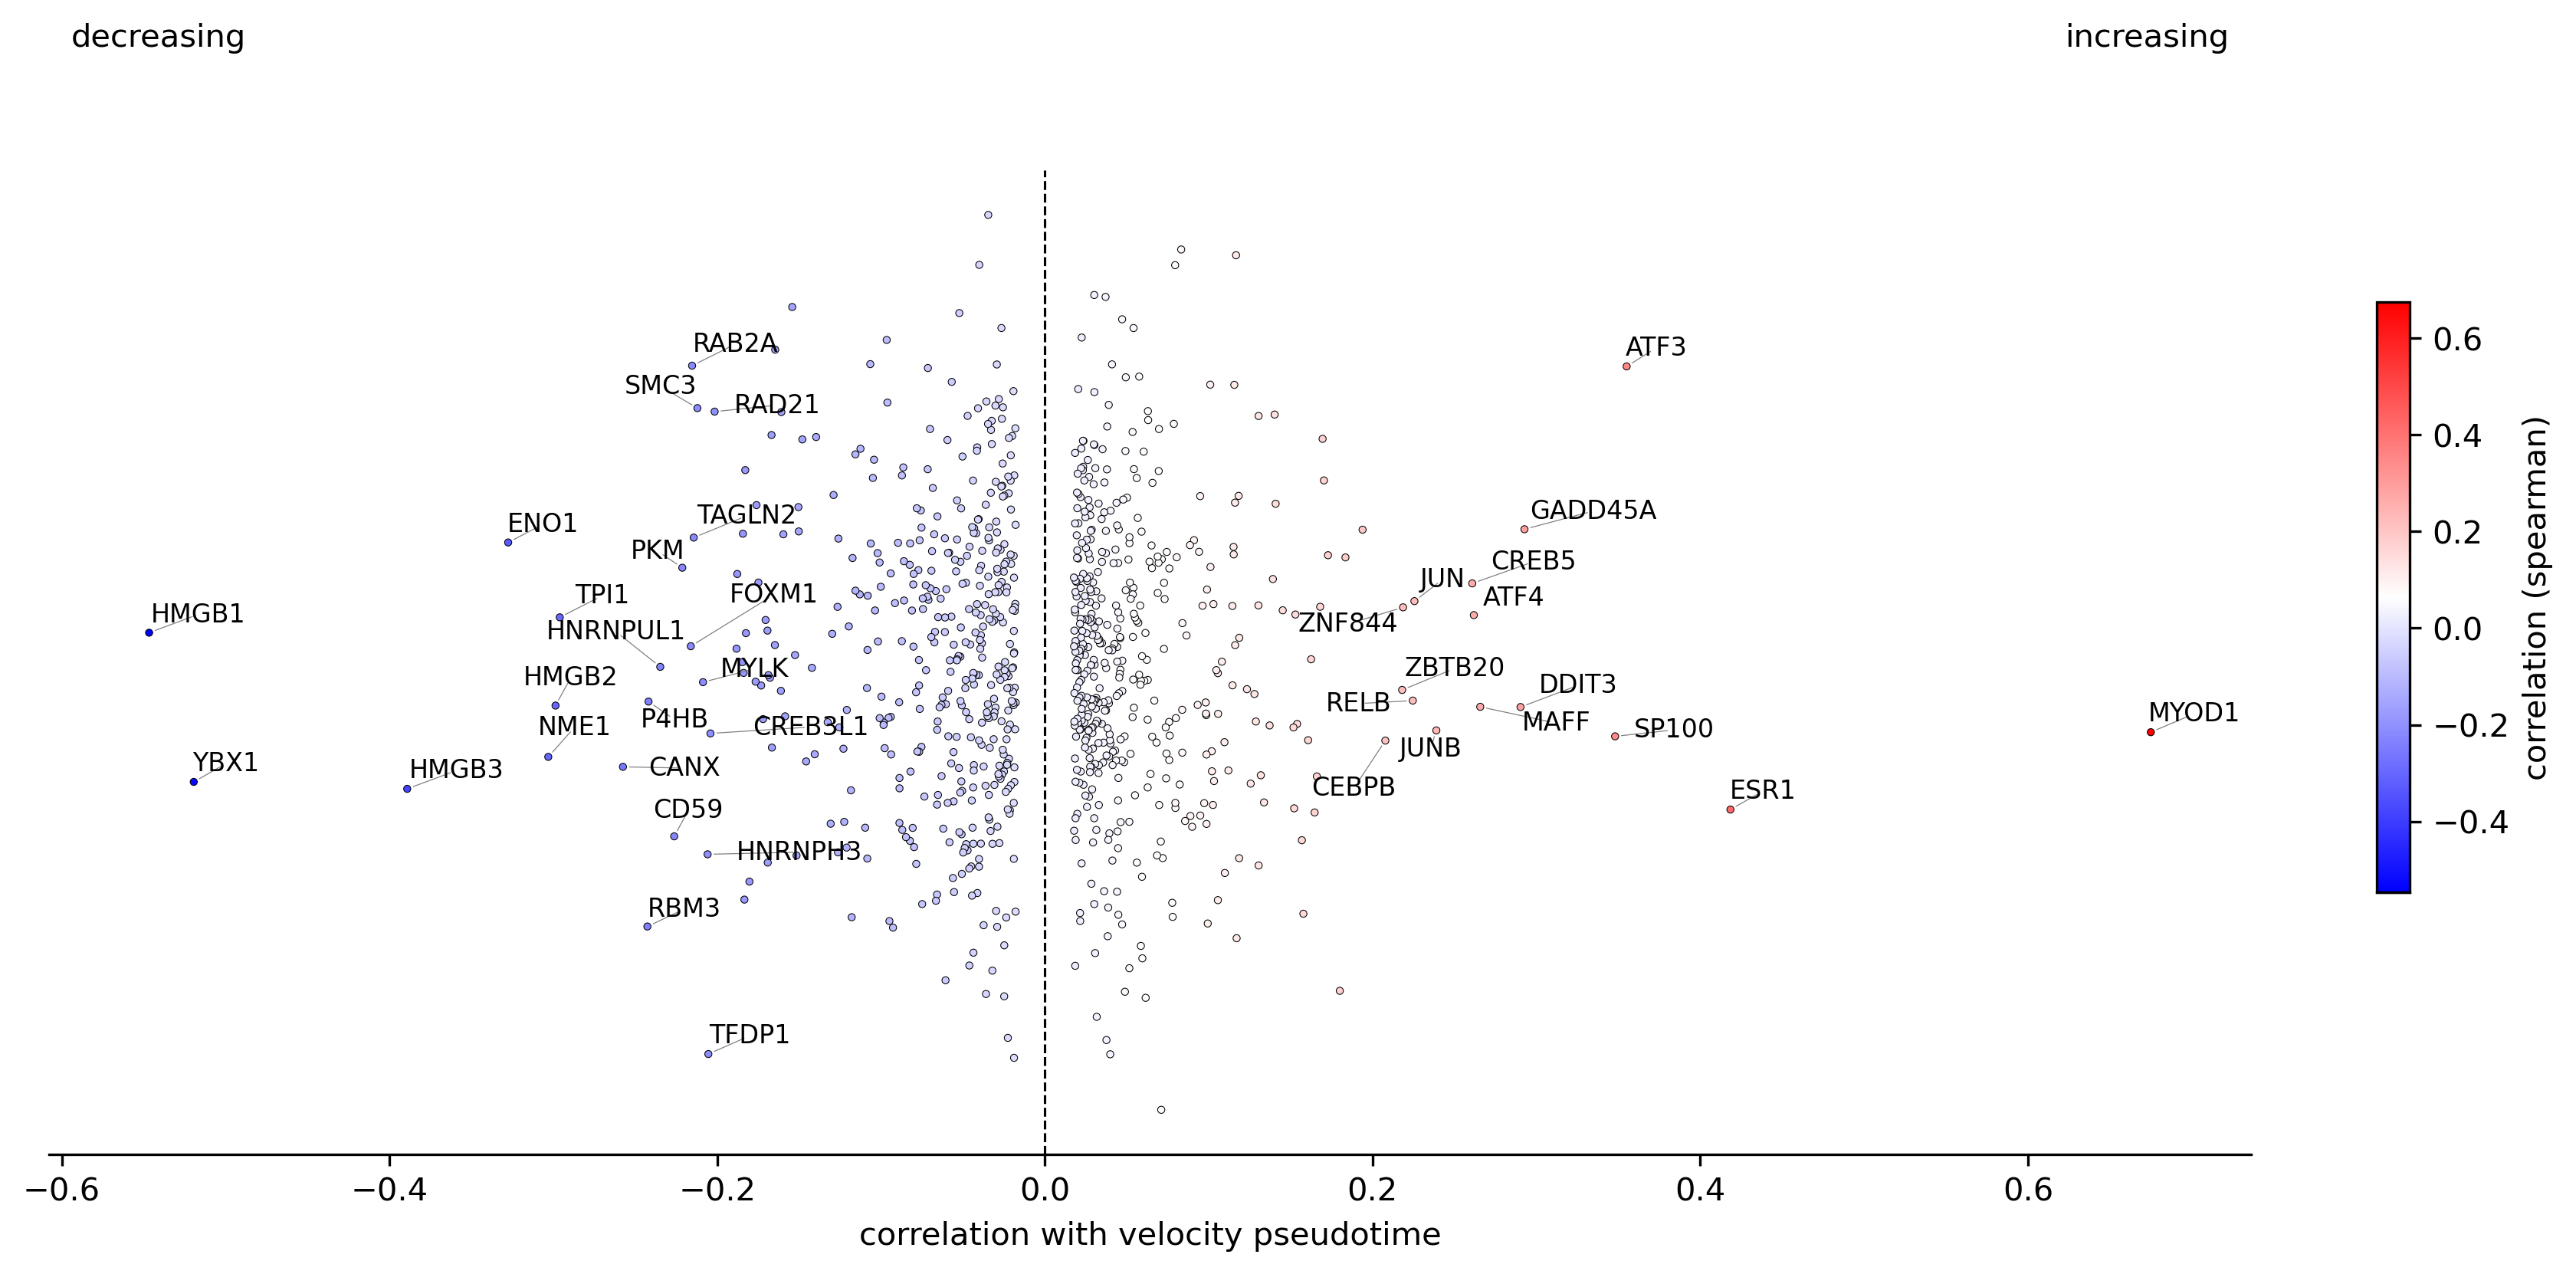

In [14]:
from adjustText import adjust_text
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# # Manually create jittered y-values
tdf['y_jitter'] = np.random.normal(loc=0, scale=0.1, size=len(tdf))

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 5), dpi=300)

# Plot scatter
sc = sns.scatterplot(
    data=tdf,
    x='correlation',
    y='y_jitter',
    hue='correlation',
    palette='bwr',
    edgecolor='k',
    linewidth=0.25,
    s=5,
    legend=False,
    zorder=3,
    ax=ax
)

# genes_to_include = ['RBFOX2', 'BCL3', 'JUN']

# Annotate genes with large correlations
texts = []
target_x = []
target_y = []
# for _, row in tdf[(abs(tdf['corr']) > 0.35) | (tdf['gene'].isin(genes_to_include))].iterrows(): # 0.35
for _, row in tdf[abs(tdf['correlation']) > 0.2].iterrows():
    texts.append(ax.text(
        row['correlation'],
        row['y_jitter'],
        row['gene'],
        fontsize=8,
        ha='center',
        va='bottom',
        zorder=4
    ))
    target_x.append(row['correlation'])
    target_y.append(row['y_jitter'])

adjust_text(
    texts,
    target_x=target_x,
    target_y=target_y,
    expand_text=(1.2, 2),
    avoid_self=True,
    ax=ax,
    arrowprops=dict(arrowstyle='-', lw=0.3, color='gray'),
    force_text=(0.75, 0.75),
)

# Add colorbar centered on right margin
norm = Normalize(vmin=tdf['correlation'].min(), vmax=tdf['correlation'].max())
sm = ScalarMappable(cmap='bwr', norm=norm)
sm.set_array([])

# Use bbox_to_anchor to shift right
cax = inset_axes(
    ax,
    width="1.5%", height="60%",
    bbox_to_anchor=(1.05, 0.25, 1, 1),  # (x0, y0, width, height) in axes fraction
    bbox_transform=ax.transAxes,
    loc='lower left'
)
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label('correlation (spearman)')

# Plot formatting
ax.axvline(x=0, c='k', lw=0.75, ls='--', zorder=0)
ax.set_xlabel('correlation with velocity pseudotime')
ax.set_ylabel('')
ax.set_yticks([])
sns.despine(left=True)
plt.tight_layout()

# Direction labels
ax.text(0.01, 1.15, "decreasing", transform=ax.transAxes, ha='left', va='top', fontsize=10)
ax.text(0.99, 1.15, "increasing", transform=ax.transAxes, ha='right', va='top', fontsize=10)

plt.show()

# Rank velocity genes

In [19]:
# scv.tl.rank_velocity_genes(adata, groupby='cluster', min_corr=.3)

df = pd.DataFrame(adata.uns['rank_velocity_genes']['names'])
print(df.head(25).to_string())

          C1        C2        C3      H1               H3        H2       M1        M2               M3        P2        P1        P3
0      PA2G4     SLFN5      SGO2    HAS2              MX1     WARS1   KIF20B     WARS1              MX1     SLFN5     AURKA     SLFN5
1     CCDC80       LUM       IL6  NUSAP1         HSP90AA1       PTN     NAV3       PTN            WARS1    RNF213     CDCA2    RNF213
2      HLA-B    EPSTI1     GTSE1    KNL1            WARS1    SQSTM1   NUSAP1     BRCA2         HSP90AA1      E2F7     MKI67      CTSK
3       MMP2    EFEMP1     H2AC6  KIF20B  ENSG00000236453    ATP2B1     KNL1       MX1  ENSG00000236453    SMURF2     NUPR1    PCDH18
4       TPM2     RSAD2      ACTB   BRCA2           PAPSS2    PAPSS2    IFIT2    ATP2B1           PAPSS2    PCDH18     POSTN     SPDL1
5      PEG10  SERPINB2    SLC3A2   EPAS1          FILIP1L    NUSAP1    PRR11     CREB5         SEPTIN11    EPSTI1    AKR1B1    EPSTI1
6     CRABP2     ITM2B     TOP2A   IFIT2           NUSAP1     

In [31]:
fpath = "../../resources/genes_for_scoring.csv"

qdf = pd.read_csv(fpath)
print(qdf.shape)
print(qdf.columns.tolist())
qdf.head()

qui_tfs = [gene for gene in qdf['quiescence'].unique() if gene in adata.var_names]
print(f"\nN quiescence TFs: {len(qui_tfs)}")

(512, 18)
['G1/S_transition', 'G2/M_transition', 'CC_checkpoints', 'Cell_cycle_reg', 'Pos_proliferation', 'Neg_proliferation', 'quiescence', 'AS', 'Chromatin', 'Circadian', 'Core_repro', 'NOTCH_signaling', 'Asymm_PCP', 'FOXO', 'p53_acyivity', 'DREAM/negE2F', 'senes_stress', 'sasp']

N quiescence TFs: 59


In [32]:
fpath = "../../resources/quiescence_markers.csv"

qdf = pd.read_csv(fpath)
print(qdf.shape)
qdf.head()

print(qdf['source'].value_counts())

# remove these genes because specific to stem cell quiescence ? 
qdf = qdf[qdf['source'] != 'Cheung_down']
qdf = qdf[qdf['source'] != 'Cheung_up']

qdf_up = qdf[qdf['source'].str.endswith('_up')]
qui_up_genes = qdf_up['gene'].unique()
print(f"\nN genes UP in quiescence: {len(qui_up_genes)}")

qdf_down = qdf[qdf['source'].str.endswith('_down')]
qui_down_genes = qdf_down['gene'].unique()
print(f"N genes DOWN in quiescence: {len(qui_down_genes)}")

(198, 2)
source
Coller_up      87
Cheung_up      38
G1_to_G0_up    30
Coller_down    24
Cheung_down    19
Name: count, dtype: int64

N genes UP in quiescence: 115
N genes DOWN in quiescence: 24


In [35]:
df.head()

,C1,C2,C3,H1,H3,H2,M1,M2,M3,P2,P1,P3
0,PA2G4,SLFN5,SGO2,HAS2,MX1,WARS1,KIF20B,WARS1,MX1,SLFN5,AURKA,SLFN5
1,CCDC80,LUM,IL6,NUSAP1,HSP90AA1,PTN,NAV3,PTN,WARS1,RNF213,CDCA2,RNF213
2,HLA-B,EPSTI1,GTSE1,KNL1,WARS1,SQSTM1,NUSAP1,BRCA2,HSP90AA1,E2F7,MKI67,CTSK
3,MMP2,EFEMP1,H2AC6,KIF20B,ENSG00000236453,ATP2B1,KNL1,MX1,ENSG00000236453,SMURF2,NUPR1,PCDH18
4,TPM2,RSAD2,ACTB,BRCA2,PAPSS2,PAPSS2,IFIT2,ATP2B1,PAPSS2,PCDH18,POSTN,SPDL1


In [36]:
gene_list = set(qui_tfs)

for col in df.columns:
    genes_in_cluster = (
        df[col]
        .dropna()
        .astype(str)
    )

    hits = sorted(set(genes_in_cluster) & gene_list)

    if hits:
        print(f"{col}: {', '.join(hits)}")
    else:
        print(f"{col}:")

C1: JUN
C2:
C3: JUN
H1:
H3: JUN
H2: JUN
M1: JUN
M2: JUN
M3: JUN
P2:
P1:
P3:


In [42]:
# qui_list = list(set(qui_up_genes) | set(qui_down_genes) | set(qui_tfs))
# print(len(qui_list))

qui_list = list(set(qui_up_genes) | set(qui_tfs))
print(len(qui_list))

173


In [43]:
gene_set = set(qui_list)

for col in df.columns:
    hits = []

    for idx, gene in df[col].items():
        if pd.notna(gene) and gene in gene_set:
            hits.append(f"{gene} ({idx})")

    if hits:
        print(f"{col}: {', '.join(hits)}")
    else:
        print(f"{col}:")

C1: NUPR1 (21), IL6 (60), HMOX1 (62), BDKRB2 (72), JUN (89), ARMC9 (90), F3 (92)
C2: SLFN5 (0), LUM (1), WNT5A (20), NEAT1 (30), ARMC9 (41), NUPR1 (54), F3 (58), BDKRB2 (62), HMOX1 (83)
C3: IL6 (1), MX1 (28), HMOX1 (32), ARMC9 (41), SLFN5 (44), NUPR1 (46), JUN (58), TPM1 (95)
H1: TPM1 (13), NEAT1 (29), LUM (38), F3 (43), HMOX1 (50), WNT5A (53), NUPR1 (69), BDKRB2 (70), MX1 (85), SLFN5 (90), IL6 (98)
H3: MX1 (0), TPM1 (10), NEAT1 (20), JUN (26), IL6 (28), SLFN5 (48), LUM (52), ARMC9 (56), BDKRB2 (65), HMOX1 (77)
H2: MX1 (13), TPM1 (16), NEAT1 (23), F3 (49), JUN (61), LUM (70), SLFN5 (78), IL6 (79), ARMC9 (82), WNT5A (84), HMOX1 (93), BDKRB2 (99)
M1: TPM1 (8), NEAT1 (27), HMOX1 (28), IL6 (30), JUN (37), F3 (41), MX1 (48), LUM (52), WNT5A (78), BDKRB2 (90), SLFN5 (97), NUPR1 (99)
M2: MX1 (3), TPM1 (21), NEAT1 (27), JUN (34), F3 (54), SLFN5 (66), WNT5A (71), IL6 (73), LUM (78), ARMC9 (83)
M3: MX1 (0), TPM1 (10), NEAT1 (24), IL6 (34), SLFN5 (40), LUM (44), JUN (45), ARMC9 (52), BDKRB2 (78),

# GEX

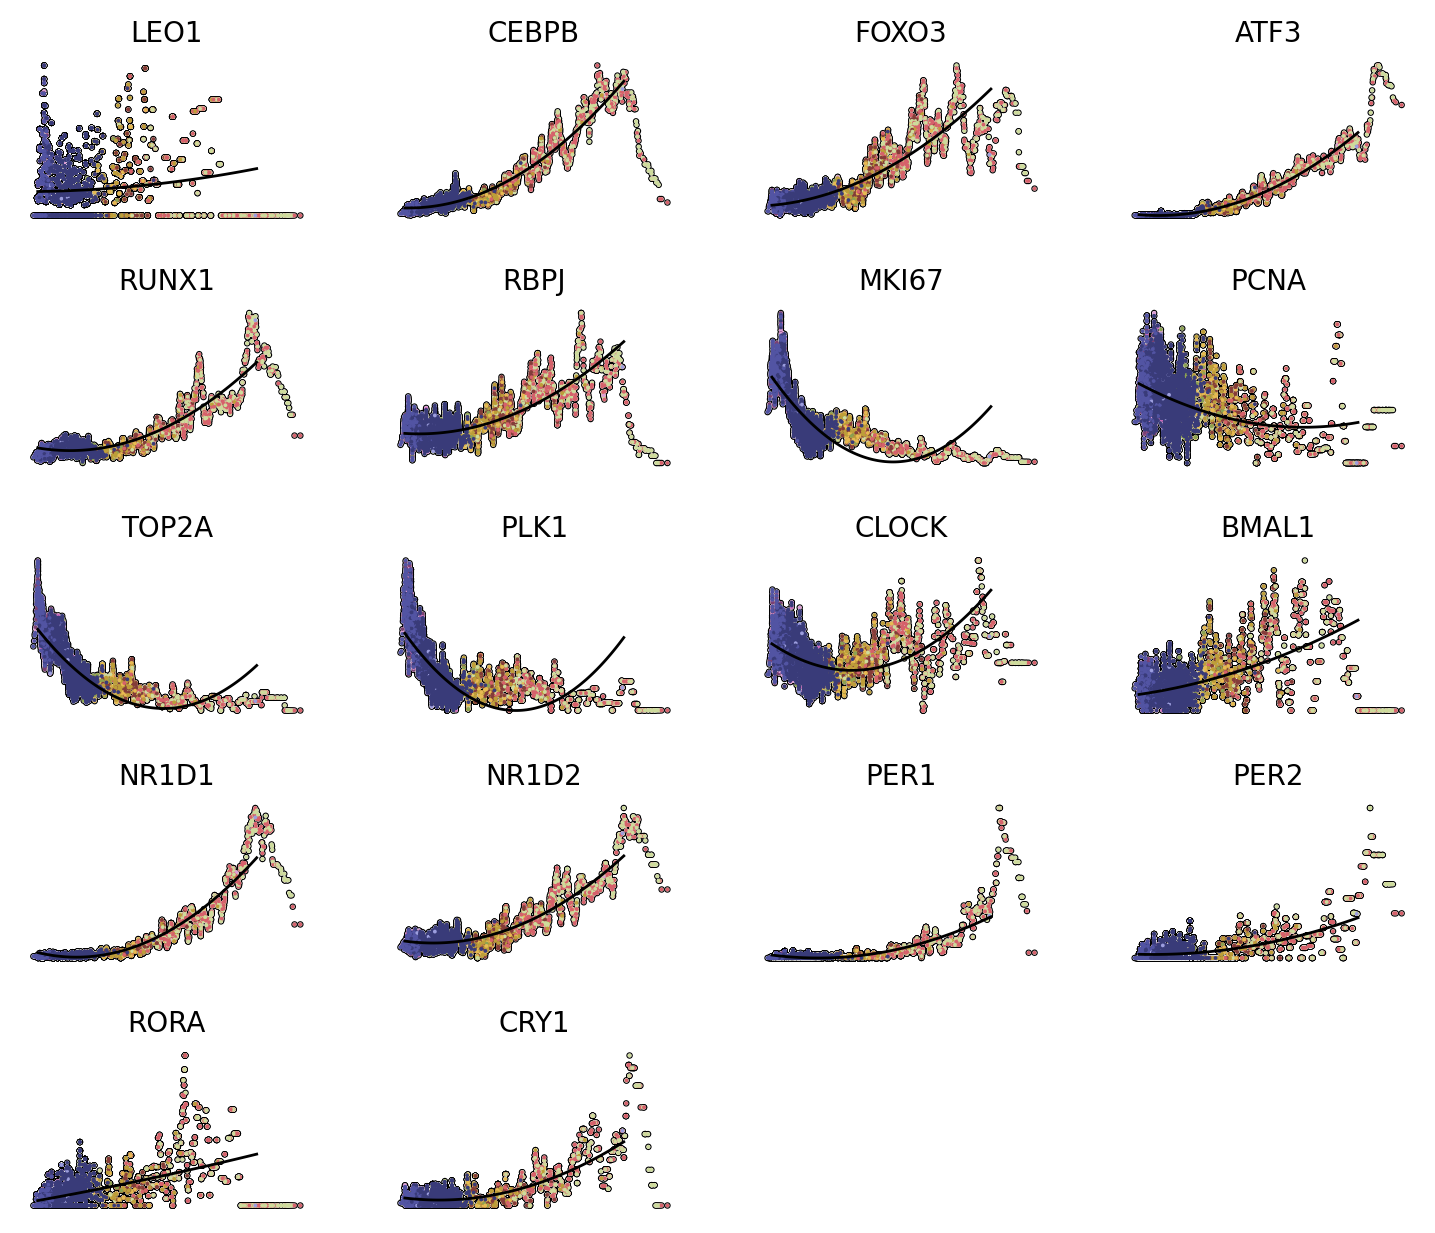

In [46]:
var_names = [
    # 'SIX1', 'MEF2A', 'MEF2C', 'DES', 'TNNT1', 'ACTN2', 'PAX3', 
    # 'PAX7', 'SIX4', 'MYF5', 'MYOD1', 'MYOG', 'MRF4',
    
    'LEO1', 'CEBPB', 'FOXO3', 'ATF3', 'RUNX1', 'RBPJ', 
    'MKI67', 'PCNA', 'TOP2A', 'PLK1', 
    'CLOCK', 'BMAL1', 'NR1D1', 'NR1D2', 'PER1', 'PER2', 'RORA', 'CRY1',
]

var_names = [g for g in var_names if g in adata.var_names]

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 2.25, 1.5

scv.pl.scatter(
    adata, 
    x='G2M_velocity_pseudotime', 
    y=var_names, 
    add_polyfit=True,
    ncols=4,
    normalize_data=True,
    add_outline=True,
    frameon=False,
    n_convolve=50,
    smooth=True,
    color='leiden_split',
    wspace=0.25,
    hspace=0.5,
    layer='spliced',
)